   Age  Experience  Salary
0   21           0   17000
1   22           1   19500
2   23           1   22500
3   24           2   26000
4   25           2   31000


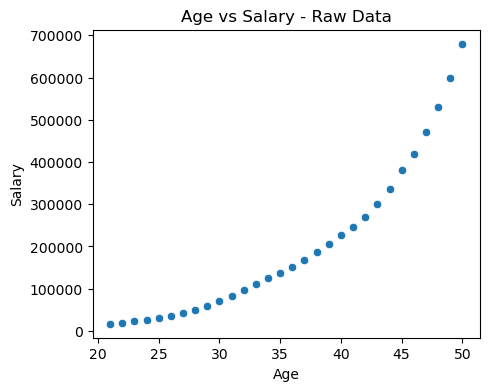

Linear Regression Results:
Mean Squared Error:  585583207.0882858
R2 Score:  0.9784616154096613


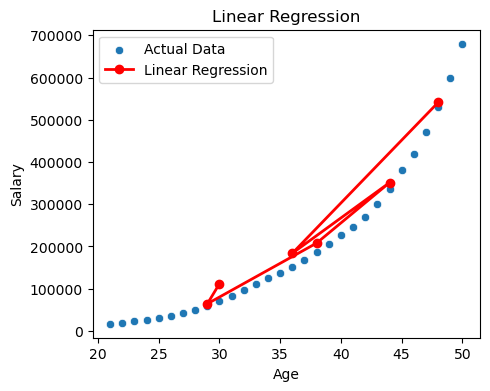


Polynomial Features:
['1' 'Age' 'Experience' 'Age^2' 'Age Experience' 'Experience^2']

Polynomial Regression Results:
Mean Squared Error:  8813825.681009805
R2 Score:  0.9996758179453715

Intercept: 1298398.2920193505
Coefficients: [      0.         -126737.01073411  217105.10825393    3127.68853234
  -10608.72560997   10660.40979056]

Prediction for Age=25, Experience=2: 31193.93


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


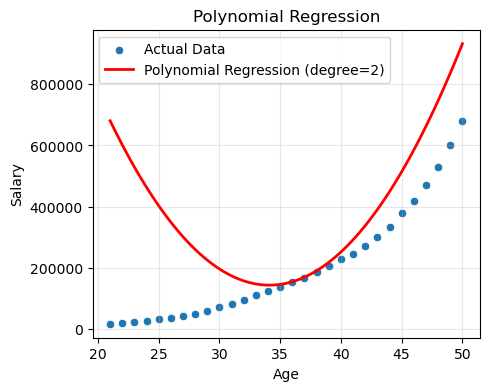

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv(r'C:/Users/mohdd/OneDrive/Documents/Desktop/Learning_Machine_Learning/MachineLearning/supervised_learning/polynomial_regression_algo/salary.csv')

# Show first few rows
print(df.head())

# Initial scatter plot
plt.figure(figsize=(5,4))
sns.scatterplot(x='Age', y='Salary', data=df)
plt.title('Age vs Salary - Raw Data')
plt.show()

# Train test split
from sklearn.model_selection import train_test_split
X = df.iloc[:,:-1]  # All columns except last
y = df['Salary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

linearModel = LinearRegression()
linearModel.fit(X_train, y_train)
y_pred = linearModel.predict(X_test)

print('Linear Regression Results:')
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred))
print('R2 Score: ', r2_score(y_test, y_pred))

# Linear regression plot
plt.figure(figsize=(5,4))
sns.scatterplot(x='Age', y='Salary', data=df, label='Actual Data')
plt.plot(X_test['Age'], y_pred, color='red', linewidth=2, label='Linear Regression', marker='o')
plt.title('Linear Regression')
plt.legend()
plt.show()

# Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# printing the x_train_poly data to see how it has been transformed
# print(f"X_train_poly: \n {X_train_poly}")

print('\nPolynomial Features:')
print(poly.get_feature_names_out())

# Train polynomial model
polyModel = LinearRegression()  # Use different name to avoid confusion
polyModel.fit(X_train_poly, y_train)
y_pred_poly = polyModel.predict(X_test_poly)

print('\nPolynomial Regression Results:')
print('Mean Squared Error: ', mean_squared_error(y_test, y_pred_poly))
print('R2 Score: ', r2_score(y_test, y_pred_poly))

print('\nIntercept:', polyModel.intercept_)
print('Coefficients:', polyModel.coef_)

# Test prediction
test_pred = polyModel.predict(poly.transform([[25, 2]]))
print(f'\nPrediction for Age=25, Experience=2: {test_pred[0]:.2f}')

# Create smooth curve for polynomial regression plot
age_range = np.linspace(df['Age'].min(), df['Age'].max(), 100).reshape(-1, 1)
experience_mean = df['Experience'].mean()
X_new = np.column_stack([age_range, np.full((100, 1), experience_mean)])

# Transform and predict
X_new_poly = poly.transform(X_new)
y_new_pred = polyModel.predict(X_new_poly)

# Final polynomial regression plot
plt.figure(figsize=(5, 4))
sns.scatterplot(x='Age', y='Salary', data=df, label='Actual Data')

# Sort by Age for smooth line
sorted_indices = np.argsort(age_range.flatten())
plt.plot(age_range[sorted_indices], y_new_pred[sorted_indices], 
         color='red', linewidth=2, label='Polynomial Regression (degree=2)')

plt.title('Polynomial Regression')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()